In [ ]:
'''
참고사항

1. weights & bias api 필요
2. google drive에 dataset이랑 checkpoint 필요
  ex)
    - checkpoint path: /content/drive/MyDrive/checkpoints/toss.ckpt
    - dataset path: /content/drive/MyDrive/datasets/TOSS_Dataset/portrait4d_rembg

3. Training 후에는 checkpoint를 google drive에 저장
  ex)
    - /content/drive/MyDrive/checkpoints/toss_lora/last.ckpt
'''

In [ ]:
!git clone https://github.com/wndyd0131/TOSS-Human-Novel-Views.git
# !git clone -b train_depth https://github.com/wndyd0131/TOSS-Human-Novel-Views.git

Cloning into 'TOSS-Human-Novel-Views'...
remote: Enumerating objects: 567, done.
remote: Counting objects: 100% (567/567), done.
remote: Compressing objects: 100% (425/425), done.
remote: Total 567 (delta 168), reused 517 (delta 118), pack-reused 0 (from 0)
Receiving objects: 100% (567/567), 21.50 MiB | 14.58 MiB/s, done.
Resolving deltas: 100% (168/168), done.


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !rsync -ah --info=progress2 "/content/drive/MyDrive/checkpoints/toss.ckpt" "/content/TOSS-Human-Novel-Views/ckpt/"

In [ ]:
# !rsync -ah --info=progress2 "/content/drive/MyDrive/datasets/TOSS_Dataset/portrait4d_rembg" "/content/TOSS-Human-Novel-Views/datasets/"

In [ ]:
!pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu121
%cd TOSS-Human-Novel-Views
!pip install -r requirements.txt
!git clone https://github.com/openai/CLIP.git
!pip install -e CLIP/

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.9/798.9 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 66.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 111.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 95.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 45.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 142.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 22.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 46.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/19

Cloning into 'CLIP'...
remote: Enumerating objects: 265, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 265 (delta 2), reused 3 (delta 1), pack-reused 257 (from 2)
Receiving objects: 100% (265/265), 8.93 MiB | 16.10 MiB/s, done.
Resolving deltas: 100% (135/135), done.
Obtaining file:///content/TOSS-Human-Novel-Views/CLIP
  Preparing metadata (setup.py) ... done
  Running setup.py develop for clip


In [ ]:
%cd /content/TOSS-Human-Novel-Views

/content/TOSS-Human-Novel-Views


# Load Model (Training)

In [ ]:
import torch
from cldm.toss import TOSS
from cldm.model import load_state_dict
from omegaconf import OmegaConf

from ldm.util import instantiate_from_config

config = OmegaConf.load("models/toss_vae.yaml")
model = instantiate_from_config(config.model)
lora_config_params = model.model.diffusion_model.peft_config['default']

checkpoint_path = "/content/drive/MyDrive/checkpoints/toss.ckpt"
# 1. Get raw state dict
raw_sd = torch.load(checkpoint_path, map_location="cpu", weights_only=False)["state_dict"] # Load parameters from checkpoint
new_sd = {}

true_count = 0
false_count = 0
# 2. Targeted Remapping
for k, v in raw_sd.items():
    # Fix the PEFT wrapper prefix first
    nk = k.replace("model.diffusion_model.", "model.diffusion_model.base_model.model.")

    # CRITICAL: If this is a LoRA target module, it MUST end in .base_layer.weight
    # Check if the original key (k) contains any of your target module names
    is_target = any(target in k for target in lora_config_params.target_modules)

    if is_target:
        true_count += 1
        # e.g., to_q.weight -> to_q.base_layer.weight
        nk = nk.replace(".weight", ".base_layer.weight")
        nk = nk.replace(".bias", ".base_layer.bias")
    else:
        false_count += 1
    new_sd[nk] = v

# 3. Load into model
missing, unexpected = model.load_state_dict(new_sd, strict=False) # Iteratre through state_dict and match the params
print("Missing:", missing) # Keys that the model has but the state_dict does not
print("Unexpected:", unexpected) # Keys that the model does not have but the state_dict does
print("True Count:", true_count)
print("False Count:", false_count)

# 4. Verify: Only lora_A/lora_B should be missing now
final_missing = [m for m in missing if "lora_" not in m]
print(f"CRITICAL MISSING (Should be empty): {final_missing}")

/usr/local/lib/python3.12/dist-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


No module 'xformers'. Proceeding without it.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/distributed.py:258: LightningDeprecationWarning: `pytorch_lightning.utilities.distributed.rank_zero_only` has been deprecated in v1.8.1 and will be removed in v2.0.0. You can import it from `pytorch_lightning.utilities` instead.
  rank_zero_deprecation(


[PATCH] Disabled gradient checkpointing in ldm_util.checkpoint
TossLoraModule: Running in eps-prediction mode
DiffusionWrapper has 863.65 M params.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: wndyd0131 (wndyd0131-sungkyunkwan-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[INIT] Modules with checkpointing enabled: 0
[INIT] Unfreezing pose_net param: base_model.model.pose_net.0.weight, shape=torch.Size([320, 51])
[INIT] Unfreezing pose_net param: base_model.model.pose_net.0.bias, shape=torch.Size([320])
[INIT] Unfreezing pose_net param: base_model.model.pose_net.2.weight, shape=torch.Size([320, 320])
[INIT] Unfreezing pose_net param: base_model.model.pose_net.2.bias, shape=torch.Size([320])
[INIT] Unfroze 4 pose_net parameters
[INIT] lora_B before init: base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight, mean=0.000000e+00
[INIT] lora_B after init: base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight, mean=1.242486e-03
[INIT] lora_B before init: base_model.model.middle_block.1.transformer_blocks.0.attn1.to_k.lora_B.default.weight, mean=0.000000e+00
[INIT] lora_B after init: base_model.model.middle_block.1.transformer_blocks.0.attn1.to_k.lora_B.default.weight, mean=1.251678e-03
[INIT] lora

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
[INIT] Initialized LPIPS perceptual loss (VGG backbone)

[DEBUG] LoRA Layer Analysis:
  base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q:
    scaling: {'default': 1.0}
    disable_adapters: False
    merged: False
    lora_A[default]: shape=torch.Size([16, 1280]), requires_grad=True
    lora_B[default]: shape=torch.Size([1280, 16]), requires_grad=True

[DEBUG] Active adapter: default
[DEBUG] Active adapters: ['default']

[DEBUG] Pose Net Weight Analysis:
  pose_net structure: Sequential(
  (0): Linear(in_features=51, out_features=320, bias=True)
  (1): SiLU()
  (2): Linear(in_features=320, out_features=320, bias=True)
)
  pose_enc type: vae

  Layer: pose_net.0.weight
    shape: torch.Size([320, 51])
    requires_grad: True
    mean: 0.000858
    std: 0.081094
    min: -0.140022
    max: 0.140011
    abs_mean: 0.070349

  Layer: pose_net.0.bias
    shape: torch.Size([320])
    requires

/usr/local/lib/python3.12/dist-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_location='cpu'), st

Missing: ['model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight', 'model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight', 'model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_k.lora_A.default.weight', 'model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_k.lora_B.default.weight', 'model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_v.lora_A.default.weight', 'model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_v.lora_B.default.weight', 'model.diffusion_model.base_model.model.output_blocks.9.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight', 'model.diffusion_model.base_model.model.output_blocks.9.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight', 'model.diffusion_model.base_model.model.output_blocks.9.1.transformer_blocks.0.attn1.to_k.lora_A

In [ ]:
for n, p in model.named_modules():
    print(n)


model
model.diffusion_model
model.diffusion_model.base_model
model.diffusion_model.base_model.model
model.diffusion_model.base_model.model.time_embed
model.diffusion_model.base_model.model.time_embed.0
model.diffusion_model.base_model.model.time_embed.1
model.diffusion_model.base_model.model.time_embed.2
model.diffusion_model.base_model.model.input_blocks
model.diffusion_model.base_model.model.input_blocks.0
model.diffusion_model.base_model.model.input_blocks.0.0
model.diffusion_model.base_model.model.input_blocks.1
model.diffusion_model.base_model.model.input_blocks.1.0
model.diffusion_model.base_model.model.input_blocks.1.0.in_layers
model.diffusion_model.base_model.model.input_blocks.1.0.in_layers.0
model.diffusion_model.base_model.model.input_blocks.1.0.in_layers.1
model.diffusion_model.base_model.model.input_blocks.1.0.in_layers.2
model.diffusion_model.base_model.model.input_blocks.1.0.h_upd
model.diffusion_model.base_model.model.input_blocks.1.0.emb_layers
model.diffusion_model.

In [ ]:
print(model)

TossLoraModule(
  (model): DiffusionWrapper(
    (diffusion_model): PeftModel(
      (base_model): LoraModel(
        (model): UNetModel_toss(
          (time_embed): Sequential(
            (0): Linear(in_features=320, out_features=1280, bias=True)
            (1): SiLU()
            (2): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (input_blocks): ModuleList(
            (0): TimestepEmbedSequential(
              (0): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            )
            (1-2): 2 x TimestepEmbedSequential(
              (0): ResBlock(
                (in_layers): Sequential(
                  (0): GroupNorm32(32, 320, eps=1e-05, affine=True)
                  (1): SiLU()
                  (2): Conv2d(320, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
                )
                (h_upd): Identity()
                (x_upd): Identity()
                (emb_layers): Sequential(
                  (0): S

In [ ]:
trainable = [n for n, p in model.named_parameters() if p.requires_grad]
print("Trainable parameters:", len(trainable))
for n in trainable:
    print(n)

Trainable parameters: 32
model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight
model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight
model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_k.lora_A.default.weight
model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_k.lora_B.default.weight
model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_v.lora_A.default.weight
model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_v.lora_B.default.weight
model.diffusion_model.base_model.model.output_blocks.9.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight
model.diffusion_model.base_model.model.output_blocks.9.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight
model.diffusion_model.base_model.model.output_blocks.9.1.transformer_blocks.0.attn1.to_k.lora_A.default.w

# Pose Methods

In [ ]:
import numpy as np

def rotation_matrix_to_euler(R):
    """
    Extract pitch (x-rotation) and yaw (y-rotation) from a 3x3 rotation matrix.
    Returns angles in radians.

    Assumes rotation order: R = Ry(yaw) @ Rx(pitch) @ Rz(roll)
    """
    # Clamp to avoid numerical issues with asin
    sy = np.clip(R[0, 2], -1.0, 1.0)
    yaw = np.arcsin(sy)

    # Check for gimbal lock
    if np.abs(sy) < 0.99999:
        pitch = np.arctan2(-R[1, 2], R[2, 2])
    else:
        pitch = np.arctan2(R[2, 1], R[1, 1])

    return pitch, yaw


def pose_matrix_to_toss_format(pose_4x4):
    """
    Convert a 4x4 pose matrix to TOSS format: [pitch, yaw, distance]

    Args:
        pose_4x4: 4x4 transformation matrix (camera-to-world or world-to-camera)

    Returns:
        [pitch, yaw, distance] as expected by TOSS pose_enc="vae" or "freq"
    """
    R = pose_4x4[:3, :3]  # 3x3 rotation
    t = pose_4x4[:3, 3]   # translation vector

    pitch, yaw = rotation_matrix_to_euler(R)

    # Distance: typically the Z component or the norm of translation
    # Adjust based on your coordinate system
    distance = np.linalg.norm(t)  # or t[2] if Z is the depth axis

    return np.array([pitch, yaw, distance], dtype=np.float32)


def compute_relative_pose(src_pose_4x4, tgt_pose_4x4):
    """
    Compute relative pose from source to target view.
    Returns [delta_pitch, delta_yaw, delta_distance] in radians.
    """
    src_pitch, src_yaw = rotation_matrix_to_euler(src_pose_4x4[:3, :3])
    tgt_pitch, tgt_yaw = rotation_matrix_to_euler(tgt_pose_4x4[:3, :3])

    src_dist = np.linalg.norm(src_pose_4x4[:3, 3])
    tgt_dist = np.linalg.norm(tgt_pose_4x4[:3, 3])

    delta_pitch = tgt_pitch - src_pitch
    delta_yaw = tgt_yaw - src_yaw
    delta_distance = tgt_dist - src_dist

    return np.array([delta_pitch, delta_yaw, delta_distance], dtype=np.float32)

# Debug: Check poses.npy format and values
import numpy as np

sub_path = "/content/drive/MyDrive/datasets/TOSS_Dataset/portrait4d_rembg/202483"
# sub_path = "datasets/portrait4d/202483"
poses = np.load(f"{sub_path}/poses.npy")

print(f"Poses shape: {poses.shape}")
print(f"Poses dtype: {poses.dtype}")

# Reshape if needed
if poses.ndim == 2 and poses.shape[1] == 16:
    poses = poses.reshape(-1, 4, 4)
    print(f"Reshaped to: {poses.shape}")

# Check a single pose matrix
print(f"\nPose[0] (view 00000):\n{poses[0]}")
print(f"\nPose[9] (view 00009 - center):\n{poses[9]}")

# Check if it looks like a valid rotation matrix
R = poses[0][:3, :3]
print(f"\nRotation matrix R (from pose[0]):\n{R}")
print(f"det(R) = {np.linalg.det(R):.6f} (should be ~1.0 for valid rotation)")
print(f"R @ R.T =\n{R @ R.T} (should be ~identity)")

# Extract angles using your function
pitch, yaw = rotation_matrix_to_euler(R)
print(f"\nExtracted angles from pose[0]:")
print(f"  pitch = {pitch:.4f} rad = {np.degrees(pitch):.2f}°")
print(f"  yaw = {yaw:.4f} rad = {np.degrees(yaw):.2f}°")

# Check all poses' yaw values
print(f"\nAll yaw values (degrees):")
for i in range(min(20, len(poses))):
    p, y = rotation_matrix_to_euler(poses[i][:3, :3])
    print(f"  View {i:02d}: pitch={np.degrees(p):+7.2f}°, yaw={np.degrees(y):+7.2f}°")

Poses shape: (20, 16)
Poses dtype: float32
Reshaped to: (20, 4, 4)

Pose[0] (view 00000):
[[ 9.5087630e-01  3.8671235e-09  3.0957130e-01  1.2411852e+00]
 [-3.9345893e-16  1.0000000e+00 -1.2491868e-08 -5.0084495e-08]
 [-3.0957130e-01  1.1878219e-08  9.5087630e-01  4.0124130e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  1.0000000e+00]]

Pose[9] (view 00009 - center):
[[ 9.9986261e-01  2.0757676e-10  1.6578235e-02  6.6313364e-02]
 [-5.3748079e-18  1.0000000e+00 -1.2521043e-08 -5.0084495e-08]
 [-1.6578235e-02  1.2519321e-08  9.9986261e-01  4.1994762e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  1.0000000e+00]]

Rotation matrix R (from pose[0]):
[[ 9.5087630e-01  3.8671235e-09  3.0957130e-01]
 [-3.9345893e-16  1.0000000e+00 -1.2491868e-08]
 [-3.0957130e-01  1.1878219e-08  9.5087630e-01]]
det(R) = 1.000000 (should be ~1.0 for valid rotation)
R @ R.T =
[[ 1.0000001e+00 -6.9490541e-16  1.8047803e-09]
 [-6.9490541e-16  1.0000000e+00 -1.8567293e-15]
 [ 1.8047803e-09 -1.8567293e-15 

# Portrait4D Dataset

In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset
import numpy as np
import torch
from torchvision import transforms as T

import os

def preprocess_normal_for_cosine(normal_rgb, valid_eps=0.1):
    """
    Preprocess normal map for cosine similarity loss.

    Args:
        normal_rgb: [H, W, 3] or [3, H, W], values in [0, 1] (standard normal map: RGB = xyz)
        valid_eps: pixels with magnitude < valid_eps in [0,1] space are invalid (e.g. black)

    Returns:
        normal: [3, H, W] L2-normalized, in [-1, 1] range
        valid_mask: [1, H, W] float, 1 where valid, 0 where invalid
    """
    if isinstance(normal_rgb, np.ndarray):
        normal = torch.from_numpy(normal_rgb).float()
    else:
        normal = normal_rgb.float()

    if normal.ndim == 3 and normal.shape[-1] == 3:
        normal = normal.permute(2, 0, 1)  # HWC -> CHW

    # Valid region: pixels where magnitude in [0,1] space > eps (exclude black/invalid)
    mag = normal.norm(dim=0, keepdim=True)
    valid_mask = (mag.squeeze(0) > valid_eps).float().unsqueeze(0)

    # RGB [0, 1] -> xyz [-1, 1]
    normal = normal * 2.0 - 1.0

    # L2 normalize per pixel (for cosine similarity)
    norm = normal.norm(dim=0, keepdim=True).clamp(min=1e-8)
    normal = normal / norm

    return normal, valid_mask

def preprocess_image(input_im):
    '''
    :param input_im (PIL Image).
    :return input_im (H, W, 3) array in [0, 1].
    '''
    input_im = input_im.resize([256, 256], Image.Resampling.LANCZOS)
    input_im = np.asarray(input_im, dtype=np.float32) / 255.0
    # (H, W, 4) array in [0, 1].

    # old method: thresholding background, very important
    # input_im[input_im[:, :, -1] <= 0.9] = [1., 1., 1., 1.]

    # new method: apply correct method of compositing to avoid sudden transitions / thresholding
    # (smoothly transition foreground to white background based on alpha values)
    if input_im.shape[-1] == 4:
        alpha = input_im[:, :, 3:4]
        white_im = np.ones_like(input_im)
        input_im = alpha * input_im + (1.0 - alpha) * white_im

    input_im = input_im[:, :, 0:3]
    # (H, W, 3) array in [0, 1].

    return input_im

class Portrait4dDataset(Dataset):
    def __init__(self, root_dir, transform=None, src_view_idx=9, skip_identity=True, load_normals=True, load_depth=True):
        super().__init__()
        self.root_dir = root_dir
        self.transform = transform
        self.src_view_idx = src_view_idx
        self.skip_identity = skip_identity
        self.load_normals = load_normals
        self.load_depth = load_depth

        self.subjects = [d for d in os.listdir(root_dir)
                         if os.path.isdir(os.path.join(root_dir, d))]
        self.samples = []
        skipped = 0

        for sub in self.subjects:
            sub_path = os.path.join(root_dir, sub)
            poses_path = os.path.join(sub_path, 'poses.npy')
            if not os.path.exists(poses_path):
                skipped += 1
                continue

            views = sorted([
                f for f in os.listdir(sub_path)
                if os.path.isfile(os.path.join(sub_path, f))
                and os.path.splitext(f)[1].lower() in [".jpg", ".png"]
                and os.path.splitext(f)[0].isdigit()
            ])
            # views = sorted([f for f in os.listdir(sub_path)
            #                if f.endswith('.jpg') and not f.startswith('src')])

            for view_file in views:
                view_id = view_file.split('.')[0]
                view_index = int(view_id)
                if self.skip_identity and view_index == self.src_view_idx:
                    continue

                mask_file = f"{view_id}_mask.png"
                normal_file = os.path.join("normals_uncropped", f"{view_id}.png")
                normal_path = os.path.join(sub_path, normal_file)
                depth_file = os.path.join("depth", f"{view_id}.npy")
                depth_path = os.path.join(sub_path, depth_file)

                has_mask = os.path.exists(os.path.join(sub_path, mask_file))
                has_normal = os.path.exists(normal_path) if self.load_normals else True
                has_depth = os.path.exists(depth_path) if self.load_depth else True

                if has_mask and has_normal and has_depth:
                    self.samples.append({
                        'sub_path': sub_path,
                        'view_file': view_file,
                        'mask_file': mask_file,
                        'normal_file': normal_file,
                        'depth_file': depth_file,
                        'view_index': view_index,
                    })

        parts = []
        if self.load_normals:
            parts.append("normals")
        if self.load_depth:
            parts.append("depth")
        extra_str = f" (with {', '.join(parts)})" if parts else ""
        print(f"[Dataset] Loaded {len(self.samples)} samples{extra_str}, skipped {skipped} incomplete subjects")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        sub_path = sample['sub_path']

        src_path = os.path.join(sub_path, f"{self.src_view_idx:05d}.png")
        src = Image.open(src_path).convert("RGBA")

        img_path = os.path.join(sub_path, sample['view_file'])
        image = Image.open(img_path).convert("RGBA")

        mask_path = os.path.join(sub_path, sample['mask_file'])
        mask = Image.open(mask_path).convert("L")

        poses = np.load(os.path.join(sub_path, 'poses.npy'))
        if poses.ndim == 2 and poses.shape[1] == 16:
            poses = poses.reshape(-1, 4, 4)

        delta_pose = compute_relative_pose(
            poses[self.src_view_idx],
            poses[sample['view_index']]
        )
        assert abs(delta_pose[1]) < 1.0, f"Yaw {delta_pose[1]} seems too large - check units!"
        delta_pose = torch.from_numpy(delta_pose).float()

        src = preprocess_image(src) # Returns [H, W, 3] numpy array
        image = preprocess_image(image) # Returns [H, W, 3] numpy array

        src = torch.from_numpy(src).permute(2, 0, 1).float()
        image = torch.from_numpy(image).permute(2, 0, 1).float()

        if self.transform:
            src = self.transform(src)
            image = self.transform(image)

        mask_transform = T.Compose([T.Resize((256, 256)), T.ToTensor()])
        mask = mask_transform(mask)

        out = {
            "jpg": image,
            "hint": src,
            "mask": mask,
            "delta_pose": delta_pose,
            "subject_id": os.path.basename(sub_path),
            "txt": ""
        }

        if self.load_normals:
            normal_path = os.path.join(sub_path, sample['normal_file'])
            normal_img = Image.open(normal_path).convert("RGB")
            normal_img = normal_img.resize((256, 256), Image.BILINEAR)
            normal_np = np.array(normal_img).astype(np.float32) / 255.0
            normal, normal_valid_mask = preprocess_normal_for_cosine(normal_np, valid_eps=0.1)
            out["normal"] = normal
            out["normal_mask"] = normal_valid_mask

        if self.load_depth:
            depth_path = os.path.join(sub_path, sample['depth_file'])
            depth_np = np.load(depth_path).astype(np.float32)
            if depth_np.ndim == 3:  # (H, W, 1) or (1, H, W) -> (H, W)
                depth_np = depth_np.squeeze()
            # Sanitize BEFORE interpolation: bilinear weights spread NaN to neighbors
            depth_np = np.nan_to_num(depth_np, nan=0.0, posinf=0.0, neginf=0.0)
            depth_t = torch.from_numpy(depth_np).float().unsqueeze(0)  # [1, H, W]
            depth_t = torch.nn.functional.interpolate(
                depth_t.unsqueeze(0), size=(256, 256),
                mode='bilinear', align_corners=False
            ).squeeze(0)  # [1, H, W]
            depth_t = torch.clamp(depth_t, min=0.0)  # ensure non-negative
            valid = (depth_t > 1e-6) & (depth_t < 1e6)
            depth_mask = valid.float()
            out["depth"] = depth_t
            out["depth_mask"] = depth_mask

        return out

from torchvision import transforms as T
from torch.utils.data import Dataset, DataLoader

transform = T.Compose([
    T.Resize((256, 256))
])

dataset_name = "portrait4d_rembg"
dataset = Portrait4dDataset(
    root_dir=f"/content/drive/MyDrive/datasets/TOSS_Dataset/portrait4d_rembg", transform=transform
)

dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)

data_iter = iter(dataloader)
batch = next(data_iter)
print("Batch keys:", batch.keys())


[Dataset] Loaded 1881 samples (with normals, depth), skipped 0 incomplete subjects
Batch keys: dict_keys(['jpg', 'hint', 'mask', 'delta_pose', 'subject_id', 'txt', 'normal', 'normal_mask', 'depth', 'depth_mask'])


# Portrait4d Dataset (Range)

In [ ]:
'''
카메라 뷰 제한용 코드

예를 들어, 정의된 set (5,7,9,11,13) 의 뷰만 batch에 넣음
적은 뷰로만 fitting시켜보기 위한 코드
'''
# import os
# from PIL import Image
# from torch.utils.data import Dataset
# import numpy as np
# import torch
# from torchvision import transforms as T

# import os

# def preprocess_normal_for_cosine(normal_rgb, valid_eps=0.1):
#     """
#     Preprocess normal map for cosine similarity loss.

#     Args:
#         normal_rgb: [H, W, 3] or [3, H, W], values in [0, 1] (standard normal map: RGB = xyz)
#         valid_eps: pixels with magnitude < valid_eps in [0,1] space are invalid (e.g. black)

#     Returns:
#         normal: [3, H, W] L2-normalized, in [-1, 1] range
#         valid_mask: [1, H, W] float, 1 where valid, 0 where invalid
#     """
#     if isinstance(normal_rgb, np.ndarray):
#         normal = torch.from_numpy(normal_rgb).float()
#     else:
#         normal = normal_rgb.float()

#     if normal.ndim == 3 and normal.shape[-1] == 3:
#         normal = normal.permute(2, 0, 1)  # HWC -> CHW

#     # Valid region: pixels where magnitude in [0,1] space > eps (exclude black/invalid)
#     mag = normal.norm(dim=0, keepdim=True)
#     valid_mask = (mag.squeeze(0) > valid_eps).float().unsqueeze(0)

#     # RGB [0, 1] -> xyz [-1, 1]
#     normal = normal * 2.0 - 1.0

#     # L2 normalize per pixel (for cosine similarity)
#     norm = normal.norm(dim=0, keepdim=True).clamp(min=1e-8)
#     normal = normal / norm

#     return normal, valid_mask

# def preprocess_image(input_im):
#     '''
#     :param input_im (PIL Image).
#     :return input_im (H, W, 3) array in [0, 1].
#     '''
#     input_im = input_im.resize([256, 256], Image.Resampling.LANCZOS)
#     input_im = np.asarray(input_im, dtype=np.float32) / 255.0
#     # (H, W, 4) array in [0, 1].

#     # old method: thresholding background, very important
#     # input_im[input_im[:, :, -1] <= 0.9] = [1., 1., 1., 1.]

#     # new method: apply correct method of compositing to avoid sudden transitions / thresholding
#     # (smoothly transition foreground to white background based on alpha values)
#     if input_im.shape[-1] == 4:
#         alpha = input_im[:, :, 3:4]
#         white_im = np.ones_like(input_im)
#         input_im = alpha * input_im + (1.0 - alpha) * white_im

#     input_im = input_im[:, :, 0:3]
#     # (H, W, 3) array in [0, 1].

#     return input_im

# class Portrait4dDataset(Dataset):
#     def __init__(
#         self,
#         root_dir,
#         transform=None,
#         src_view_idx=9,
#         skip_identity=True,
#         load_normals=False,
#         view_indices=None,
#         hint_filename=None,
#     ):
#         super().__init__()
#         self.root_dir = root_dir
#         self.transform = transform
#         self.src_view_idx = src_view_idx
#         self.skip_identity = skip_identity
#         self.load_normals = load_normals
#         self.view_indices = view_indices
#         self._view_indices_set = None if view_indices is None else frozenset(view_indices)
#         self.hint_filename = hint_filename

#         self.subjects = [d for d in os.listdir(root_dir)
#                         if os.path.isdir(os.path.join(root_dir, d))]
#         self.samples = []

#         skipped = 0
#         for sub in self.subjects:
#             sub_path = os.path.join(root_dir, sub)
#             poses_path = os.path.join(sub_path, 'poses.npy')

#             if not os.path.exists(poses_path):
#                 skipped += 1
#                 continue

#             views = sorted([
#                 f for f in os.listdir(sub_path)
#                 if (f.lower().endswith('.jpg') or f.lower().endswith('.png'))
#                 and f.split('.')[0].isdigit()
#             ])

#             for view_file in views:
#                 view_id = view_file.split('.')[0]
#                 view_index = int(view_id)

#                 if self._view_indices_set is not None and view_index not in self._view_indices_set:
#                     continue

#                 if self.skip_identity and view_index == self.src_view_idx:
#                     continue

#                 mask_file = f"{view_id}_mask.png"
#                 normal_file = os.path.join("normals_uncropped", f"{view_id}.png")
#                 normal_path = os.path.join(sub_path, normal_file)

#                 has_mask = os.path.exists(os.path.join(sub_path, mask_file))
#                 has_normal = os.path.exists(normal_path) if self.load_normals else True

#                 if has_mask and has_normal:
#                     self.samples.append({
#                         'sub_path': sub_path,
#                         'view_file': view_file,
#                         'mask_file': mask_file,
#                         'normal_file': normal_file,
#                         'view_index': view_index
#                     })

#         norm_str = " (with normals)" if self.load_normals else ""
#         print(f"[Dataset] Loaded {len(self.samples)} samples{norm_str}, skipped {skipped} incomplete subjects")

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         sample = self.samples[idx]
#         sub_path = sample['sub_path']

#         if self.hint_filename is None:
#             hint_path = os.path.join(sub_path, f"{self.src_view_idx:05d}.png")
#         else:
#             hint_path = os.path.join(sub_path, self.hint_filename)
#         src = Image.open(hint_path).convert("RGBA")

#         img_path = os.path.join(sub_path, sample['view_file'])
#         image = Image.open(img_path).convert("RGBA")

#         mask_path = os.path.join(sub_path, sample['mask_file'])
#         mask = Image.open(mask_path).convert("L")

#         poses = np.load(os.path.join(sub_path, 'poses.npy'))
#         if poses.ndim == 2 and poses.shape[1] == 16:
#             poses = poses.reshape(-1, 4, 4)

#         delta_pose = compute_relative_pose(
#             poses[self.src_view_idx],
#             poses[sample['view_index']]
#         )
#         assert abs(delta_pose[1]) < 1.0, f"Yaw {delta_pose[1]} seems too large - check units!"
#         delta_pose = torch.from_numpy(delta_pose).float()

#         src = preprocess_image(src) # Returns [H, W, 3] numpy array
#         image = preprocess_image(image) # Returns [H, W, 3] numpy array

#         src = torch.from_numpy(src).permute(2, 0, 1).float()
#         image = torch.from_numpy(image).permute(2, 0, 1).float()

#         if self.transform:
#             src = self.transform(src)
#             image = self.transform(image)

#         mask_transform = T.Compose([T.Resize((256, 256)), T.ToTensor()])
#         mask = mask_transform(mask)

#         out = {
#             "jpg": image,
#             "hint": src,
#             "mask": mask,
#             "delta_pose": delta_pose,
#             "subject_id": os.path.basename(sub_path),
#             "txt": ""
#         }

#         if self.load_normals:
#             normal_path = os.path.join(sub_path, sample['normal_file'])
#             normal_img = Image.open(normal_path).convert("RGB")
#             normal_img = normal_img.resize((256, 256), Image.BILINEAR)
#             normal_np = np.array(normal_img).astype(np.float32) / 255.0  # [H, W, 3]

#             normal, normal_valid_mask = preprocess_normal_for_cosine(normal_np, valid_eps=0.1)
#             out["normal"] = normal
#             out["normal_mask"] = normal_valid_mask  # valid region for geometry loss

#         return out

# from torchvision import transforms as T
# from torch.utils.data import Dataset, DataLoader

# transform = T.Compose([
#     T.Resize((256, 256)),
#     view_indices=(5,7,9,11,13)
# ])

# dataset_name = "portrait4d_rembg"
# dataset = Portrait4dDataset(
#     root_dir=f"/content/drive/MyDrive/datasets/TOSS_Dataset/portrait4d_rembg", transform=transform
# )

# dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)

# data_iter = iter(dataloader)
# batch = next(data_iter)
# print("Batch keys:", batch.keys())

# Depth Visualization

In [ ]:
# import matplotlib.pyplot as plt
# import torch

# ds = Portrait4dDataset(root_dir=f"/content/drive/MyDrive/datasets/TOSS_Dataset/portrait4d_rembg", transform=transform)

# for i in [0, 10, 20]:
#     item = ds[i]
#     img = item["jpg"].permute(1, 2, 0).cpu().numpy()
#     depth = item["depth"][0].cpu()
#     depth_mask = item["depth_mask"][0].cpu()
#     seg_mask = item["mask"][0].cpu()

#     valid = depth_mask > 0.5
#     overlap = valid & (seg_mask > 0.5)

#     print(f"sample {i}")
#     print("depth shape:", depth.shape)
#     print("valid ratio:", valid.float().mean().item())
#     print("seg ratio:", (seg_mask > 0.5).float().mean().item())
#     if valid.any():
#         v = depth[valid]
#         print("depth min/max/mean:", v.min().item(), v.max().item(), v.mean().item())

#     fig, ax = plt.subplots(1, 4, figsize=(16, 4))
#     ax[0].imshow(img)
#     ax[0].set_title("RGB")
#     ax[1].imshow(depth.numpy(), cmap="viridis")
#     ax[1].set_title("Depth")
#     ax[2].imshow(depth_mask.numpy(), cmap="gray")
#     ax[2].set_title("Depth mask")
#     ax[3].imshow(overlap.numpy(), cmap="gray")
#     ax[3].set_title("Overlap")
#     for a in ax:
#         a.axis("off")
#     plt.show()

# Training

In [ ]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint

checkpoint_cb = ModelCheckpoint(
    dirpath="/content/drive/MyDrive/checkpoints/toss_lora/",
    filename="toss-{step}",
    save_last=True,
    every_n_train_steps=500
)

trainer = pl.Trainer(
    max_steps=1000, # 1 step = 1 batch(4)
    accelerator="gpu",
    devices=1,
    callbacks=[checkpoint_cb],
    log_every_n_steps=10,
    gradient_clip_val=1.0,
    enable_checkpointing=True,
)

# Additional Config
model.learning_rate = 1e-5
model.sd_locked = True
model.first_stage_key = "jpg"
model.control_key = "hint"
model.cond_stage_key = "txt"

import torch.utils.checkpoint as cp
cp.checkpoint = lambda func, *args, **kwargs: func(*args)

trainer.fit(model, dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:108: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn(
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbac

[OPT] LoRA param: base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight, shape=torch.Size([16, 1280])
[OPT] LoRA param: base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight, shape=torch.Size([1280, 16])
[OPT] LoRA param: base_model.model.middle_block.1.transformer_blocks.0.attn1.to_k.lora_A.default.weight, shape=torch.Size([16, 1280])
[OPT] LoRA param: base_model.model.middle_block.1.transformer_blocks.0.attn1.to_k.lora_B.default.weight, shape=torch.Size([1280, 16])
[OPT] LoRA param: base_model.model.middle_block.1.transformer_blocks.0.attn1.to_v.lora_A.default.weight, shape=torch.Size([16, 1280])
[OPT] LoRA param: base_model.model.middle_block.1.transformer_blocks.0.attn1.to_v.lora_B.default.weight, shape=torch.Size([1280, 16])
[OPT] LoRA param: base_model.model.output_blocks.9.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight, shape=torch.Size([16, 320])
[OPT] LoRA param: base_model.model.output_blocks.9.1.transfo

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 12 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

[TRAIN] Training step 0, verifying LoRA setup...
[TRAIN] Found 108 LoRA modules in forward path
[TRAIN] base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight: mean=1.391195e-02, requires_grad=True
[TRAIN] base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight: mean=1.242485e-03, requires_grad=True
[TRAIN] base_model.model.middle_block.1.transformer_blocks.0.attn1.to_k.lora_A.default.weight: mean=1.395367e-02, requires_grad=True
[TRAIN] base_model.model.middle_block.1.transformer_blocks.0.attn1.to_k.lora_B.default.weight: mean=1.251678e-03, requires_grad=True
[TRAIN] base_model.model.middle_block.1.transformer_blocks.0.attn1.to_v.lora_A.default.weight: mean=1.400383e-02, requires_grad=True
[TRAIN] base_model.model.middle_block.1.transformer_blocks.0.attn1.to_v.lora_B.default.weight: mean=1.254277e-03, requires_grad=True
[TRAIN] base_model.model.output_blocks.9.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight: mean=2.8

...


DDIM Sampler:  90%|█████████ | 18/20 [00:01<00:00, 12.75it/s]


[HOOK] base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q:
  input mean: 0.152296
  lora_A(x) mean: 0.089530
  lora_B(lora_A(x)) mean: 0.000509
  scaling: 1.0
  lora_contribution mean: 0.000509
  output mean: 0.483227

[HOOK] base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q:
  input mean: 0.152296
  lora_A(x) mean: 0.089530
  lora_B(lora_A(x)) mean: 0.000509
  scaling: 1.0
  lora_contribution mean: 0.000509
  output mean: 0.483227



DDIM Sampler: 100%|██████████| 20/20 [00:01<00:00, 12.75it/s]



[HOOK] base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q:
  input mean: 0.143699
  lora_A(x) mean: 0.087572
  lora_B(lora_A(x)) mean: 0.000503
  scaling: 1.0
  lora_contribution mean: 0.000503
  output mean: 0.462920

[HOOK] base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q:
  input mean: 0.143699
  lora_A(x) mean: 0.087572
  lora_B(lora_A(x)) mean: 0.000503
  scaling: 1.0
  lora_contribution mean: 0.000503
  output mean: 0.462920
[VIS] Logged multiview predictions at step 0

[BACKWARD HOOK] lora_B gradient received!
  grad shape: torch.Size([1280, 16])
  grad mean: 6.18291151610606e-09

[BACKWARD HOOK] lora_B gradient received!
  grad shape: torch.Size([1280, 16])
  grad mean: 6.18291151610606e-09

[GRAD CHECK] Step 0
  LoRA params (24):
    lora_A: norm=1.02e-07, mean=5.32e-10, max=9.76e-09
    lora_B: norm=1.28e-06, mean=6.18e-09, max=8.18e-08
    lora_A: norm=1.13e-07, mean=5.89e-10, max=9.50e-09
    lora_B: norm=1.22e-06, mean=6.15e-09, max=4.48e-08
  

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py:48: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


# Inference
아래 두 체크 포인트 모두 로드 필요

## Load Model + TOSS Checkpoint

In [ ]:
from PIL import Image
import numpy as np
import torchvision.transforms as T

# Load the last checkpoint
import torch
from cldm.toss import TOSS
from cldm.toss_lora import TossLoraModule
from cldm.model import load_state_dict
from omegaconf import OmegaConf
from PIL import Image
from torchvision import transforms as T

from ldm.util import instantiate_from_config

config = OmegaConf.load("models/toss_vae.yaml")
model = instantiate_from_config(config.model)

print(isinstance(model, TossLoraModule))

state_dict = torch.load("ckpt/toss.ckpt", map_location="cpu", weights_only=False)["state_dict"]

model.load_state_dict(state_dict, strict=False)

for n, p in model.named_parameters():
   if "lora" in n.lower() or ".out." in n.lower():
       print(n, p.abs().mean().item())

## Load TOSS_LORA Checkpoint

In [ ]:
trained_ckpt = torch.load("checkpoints/v2/last-v12.ckpt", map_location="cpu", weights_only=False)

lora_keys = [k for k in trained_ckpt["state_dict"].keys() if "lora" in k.lower()]
print(f"Found {len(lora_keys)} LoRA keys in checkpoint:")
for k in lora_keys:
    print(f"  {k}: {trained_ckpt['state_dict'][k].abs().mean().item():.6f}")

# This will inject your LoRA weights and your trained PoseNet
m, u = model.load_state_dict(trained_ckpt["state_dict"], strict=False)

print()

for n, p in model.named_parameters():
   if "lora" in n.lower() or ".out." in n.lower():
       print(n, p.abs().mean().item())

print("Missing:", m)
print("Unexpected keys (should be empty):", u)

# TOSS_LORA Inference

In [ ]:
"""
TOSS inference API for notebooks — same sampling pipeline as app.py (no Gradio, no CLI).

Example:
    from inference import TossInference
    runner = TossInference(resume_path="ckpt/toss.ckpt")
    out = runner.generate("input.png", prompt="a red shoe", dy=-90)
    out = runner.generate(pil_image, prompt="", dx=0, dy=0, dz=0)
"""
from __future__ import annotations

from pathlib import Path
from types import SimpleNamespace
from typing import Union

import numpy as np
import torch
from einops import rearrange
from omegaconf import OmegaConf
from PIL import Image
from pytorch_lightning import seed_everything
from torchvision import transforms

from ldm.models.diffusion.ddim import DDIMSampler

from app import get_T_from_relative, preprocess_image, sample_model

def load_model(device, _hparams, sd_locked, only_mid_control, cfgs):
    model = instantiate_from_config(cfgs.model)

    # Load the state dict
    state_dict = torch.load("/content/drive/MyDrive/checkpoints/toss.ckpt", map_location="cpu", weights_only=False)["state_dict"]

    # --- FIX START ---
    # Remove the problematic key if it exists
    key_to_remove = "cond_stage_model.transformer.text_model.embeddings.position_ids"
    if key_to_remove in state_dict:
        print(f"Removing {key_to_remove} from state_dict to match model structure.")
        del state_dict[key_to_remove]
    # --- FIX END ---

    model.load_state_dict(state_dict, strict=False) # Adding strict=False is a safe backup

    trained_ckpt = torch.load("/content/drive/MyDrive/checkpoints/toss_lora/last.ckpt", map_location="cpu", weights_only=False)

    lora_keys = [k for k in trained_ckpt["state_dict"].keys() if "lora" in k.lower()]
    print(f"Found {len(lora_keys)} LoRA keys in checkpoint:")
    for k in lora_keys:
        print(f"  {k}: {trained_ckpt['state_dict'][k].abs().mean().item():.6f}")

    # This will inject your LoRA weights and your trained PoseNet
    m, u = model.load_state_dict(trained_ckpt["state_dict"], strict=False)

    print()

    for n, p in model.named_parameters():
      if "lora" in n.lower() or ".out." in n.lower():
          print(n, p.abs().mean().item())

    print("Missing:", m)
    print("Unexpected keys (should be empty):", u)

    # reweight noise scheduler
    if _hparams.register_scheduler:
        model.register_schedule(given_betas=None, beta_schedule="linear", timesteps=1000, linear_start=0.00085, linear_end=0.016)

    model.learning_rate = _hparams.lr
    model.sd_locked = sd_locked
    model.only_mid_control = only_mid_control
    model = model.to(device)
    model.eval()
    return model

ImageInput = Union[str, Path, Image.Image, np.ndarray]


def _to_pil_rgba(image: ImageInput) -> Image.Image:
    if isinstance(image, (str, Path)):
        return Image.open(image).convert("RGBA")
    if isinstance(image, Image.Image):
        return image.convert("RGBA")
    if isinstance(image, np.ndarray):
        arr = image
        if arr.dtype != np.uint8:
            arr = np.clip(arr, 0.0, 1.0)
            if arr.max() <= 1.0:
                arr = (arr * 255.0).astype(np.uint8)
            else:
                arr = arr.astype(np.uint8)
        if arr.ndim == 2:
            raise ValueError("grayscale numpy arrays are not supported; use RGB/RGBA")
        if arr.shape[-1] == 4:
            return Image.fromarray(arr, mode="RGBA")
        if arr.shape[-1] == 3:
            return Image.fromarray(arr, mode="RGB").convert("RGBA")
        raise ValueError(f"expected HxWx3 or HxWx4 array, got shape {arr.shape}")
    raise TypeError(f"unsupported image type: {type(image)}")

class TossInference:
    """Load TOSS once, then call ``generate`` with varying inputs (notebook-friendly)."""

    def __init__(
        self,
        model_cfg: str | Path = "models/toss_vae.yaml",
        resume_path: str | Path = "/content/drive/MyDrive/checkpoints/toss.ckpt",
        *,
        device: torch.device | str | None = None,
        gpu: int = 0,
        register_scheduler: bool = False,
        lr: float = 1e-4,
        seed: int = 40,
        sd_locked: bool = True,
        only_mid_control: bool = False,
        use_ema_scope: bool = True,
        pose_enc: str = "freq",
        h: int = 256,
        w: int = 256,
    ):
        """
        Args:
            model_cfg: YAML defining the model (e.g. ``models/toss_vae.yaml``).
            resume_path: Checkpoint with ``state_dict`` (e.g. ``ckpt/toss.ckpt``).
            device: Explicit device; if None, uses ``cuda:{gpu}`` when available.
            gpu: CUDA index when ``device`` is None.
            register_scheduler: Passed through to ``load_model`` (same as training flag).
            lr: Required by ``load_model``; not used during inference.
            seed: Fixed at init; call ``set_seed`` to change between runs.
            use_ema_scope / pose_enc / h / w: Defaults for ``generate`` (overridable per call).
        """
        seed_everything(seed, workers=True)
        if device is None:
            self.device = torch.device(
                f"cuda:{gpu}" if torch.cuda.is_available() else "cpu"
            )
        else:
            self.device = torch.device(device)

        hparams = SimpleNamespace(
            resume_path=str(resume_path),
            register_scheduler=register_scheduler,
            lr=lr,
        )
        cfgs = OmegaConf.load(str(model_cfg))
        self.model = load_model(
            self.device, hparams, sd_locked, only_mid_control, cfgs
        )

        trainable = [n for n, p in self.model.named_parameters() if p.requires_grad]
        print("Trainable parameters:", len(trainable))
        for n in trainable:
            print(n)

        self.sampler = DDIMSampler(self.model)

        self._default_use_ema_scope = use_ema_scope
        self._default_pose_enc = pose_enc
        self._default_h = h
        self._default_w = w

    def set_seed(self, seed: int) -> None:
        """Call between ``generate`` runs for reproducible DDIM noise."""
        seed_everything(seed, workers=True)

    @torch.no_grad()
    def generate(
        self,
        image: ImageInput,
        prompt: str = "",
        dx: float = 0.0,
        dy: float = 0.0,
        dz: float = 0.0,
        *,
        pose_enc: str | None = None,
        h: int | None = None,
        w: int | None = None,
        precision: str = "fp32",
        n_samples: int = 1,
        use_ema_scope: bool | None = None,
        ddim_steps: int = 75,
        ddim_eta: float = 1.0,
        prompt_scale: float = 5.0,
        img_scale: float = 3.0,
        img_ucg: float = 0.05,
    ) -> Image.Image:
        """
        Novel view for one image (same logic as ``app.generate_loop_views`` / ``sample_model``).

        Args:
            image: Path, ``PIL.Image``, or ``HxWx3`` / ``HxWx4`` numpy array (float or uint8).
            prompt: Text conditioning (empty string allowed).
            dx, dy, dz: Relative pose in degrees / distance (see ``app.get_T_from_relative``).
        """
        h = self._default_h if h is None else h
        w = self._default_w if w is None else w
        pose_enc = self._default_pose_enc if pose_enc is None else pose_enc
        if use_ema_scope is None:
            use_ema_scope = self._default_use_ema_scope

        cond_im_pil = _to_pil_rgba(image)
        cond_im = preprocess_image(cond_im_pil)
        cond_im = transforms.ToTensor()(cond_im).unsqueeze(0).to(self.device)
        cond_im = transforms.functional.resize(cond_im, [h, w])

        T = get_T_from_relative(dx, dy, dz, pose_enc)
        x_samples = sample_model(
            cond_im,
            self.model,
            self.sampler,
            precision=precision,
            h=h,
            w=w,
            ddim_steps=ddim_steps,
            n_samples=n_samples,
            prompt_scale=prompt_scale,
            img_scale=img_scale,
            ddim_eta=ddim_eta,
            T=T,
            use_ema_scope=use_ema_scope,
            prompt=prompt,
            img_ucg=img_ucg,
        )
        assert x_samples.shape[0] == 1
        out = x_samples[0].cpu().numpy()
        out = 255.0 * rearrange(out, "c h w -> h w c")
        return Image.fromarray(out.astype(np.uint8))

In [ ]:
toss = TossInference()

INFO:lightning_fabric.utilities.seed:Global seed set to 40


TossLoraModule: Running in eps-prediction mode
DiffusionWrapper has 863.65 M params.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels


[INIT] Modules with checkpointing enabled: 0
[INIT] Unfreezing pose_net param: base_model.model.pose_net.0.weight, shape=torch.Size([320, 51])
[INIT] Unfreezing pose_net param: base_model.model.pose_net.0.bias, shape=torch.Size([320])
[INIT] Unfreezing pose_net param: base_model.model.pose_net.2.weight, shape=torch.Size([320, 320])
[INIT] Unfreezing pose_net param: base_model.model.pose_net.2.bias, shape=torch.Size([320])
[INIT] Unfroze 4 pose_net parameters
[INIT] lora_B before init: base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight, mean=0.000000e+00
[INIT] lora_B after init: base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight, mean=1.248942e-03
[INIT] lora_B before init: base_model.model.middle_block.1.transformer_blocks.0.attn1.to_k.lora_B.default.weight, mean=0.000000e+00
[INIT] lora_B after init: base_model.model.middle_block.1.transformer_blocks.0.attn1.to_k.lora_B.default.weight, mean=1.247678e-03
[INIT] lora

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
[INIT] Initialized LPIPS perceptual loss (VGG backbone)

[DEBUG] LoRA Layer Analysis:
  base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q:
    scaling: {'default': 1.0}
    disable_adapters: False
    merged: False
    lora_A[default]: shape=torch.Size([16, 1280]), requires_grad=True
    lora_B[default]: shape=torch.Size([1280, 16]), requires_grad=True

[DEBUG] Active adapter: default
[DEBUG] Active adapters: ['default']

[DEBUG] Pose Net Weight Analysis:
  pose_net structure: Sequential(
  (0): Linear(in_features=51, out_features=320, bias=True)
  (1): SiLU()
  (2): Linear(in_features=320, out_features=320, bias=True)
)
  pose_enc type: vae

  Layer: pose_net.0.weight
    shape: torch.Size([320, 51])
    requires_grad: True
    mean: -0.001105
    std: 0.080801
    min: -0.140027
    max: 0.140027
    abs_mean: 0.069902

  Layer: pose_net.0.bias
    shape: torch.Size([320])
    require

/usr/local/lib/python3.12/dist-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_location='cpu'), st

Removing cond_stage_model.transformer.text_model.embeddings.position_ids from state_dict to match model structure.
Found 24 LoRA keys in checkpoint:
  model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight: 0.014079
  model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight: 0.001963
  model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_k.lora_A.default.weight: 0.014110
  model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_k.lora_B.default.weight: 0.002026
  model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_v.lora_A.default.weight: 0.014915
  model.diffusion_model.base_model.model.middle_block.1.transformer_blocks.0.attn1.to_v.lora_B.default.weight: 0.002981
  model.diffusion_model.base_model.model.output_blocks.9.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight: 0.028621
  model.

In [ ]:
img_name = "man_head.png"
src_img = Image.open(f"{img_name}").convert("RGBA")

image = toss.generate(
    image=src_img,
    prompt="",
    dy=20.0,
)

POSE_ENC: freq
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 77 timesteps



DDIM Sampler: 100%|██████████| 77/77 [00:10<00:00,  7.55it/s]

torch.Size([1, 4, 32, 32])


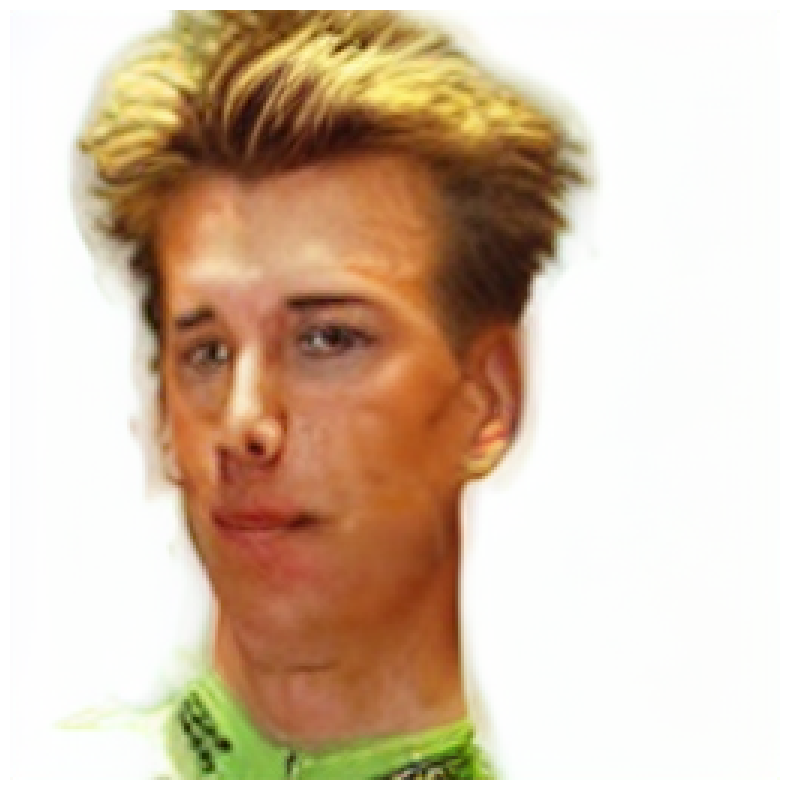

In [ ]:
import matplotlib.pyplot as plt

# 1. Take the first image in the batch: [3, H, W]
# 2. Permute dimensions to: [H, W, 3]
# img_to_show = out[0].permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off') # Hide the x/y coordinates
plt.show()

# Legacy codes

In [ ]:
# model.cuda()
# model.eval()

# # source image
# img_name = "00010.jpg"
# src_img = Image.open(f"examples/{img_name}").convert("RGB")

# transform = T.Compose([
#     T.Resize((256, 256)),
#     T.ToTensor(),
#     T.Normalize([0.5]*3, [0.5]*3)  # → [-1,1]
# ])

# src_img = transform(src_img)
# src_img = src_img.unsqueeze(0).cuda()
# print(src_img.shape)

# with torch.no_grad():
#     z = model.encode_first_stage(src_img)
#     z = model.get_first_stage_encoding(z)
# print(z.shape)

# # with torch.no_grad():
# #     hint_post = model.encode_first_stage(src_img)
# #     hint_latent = hint_post.mode() if hasattr(hint_post, "mode") else hint_post



# # pose (example)
# # delta_pose = torch.eye(4)[:3]   # (3,4)
# # delta_pose = delta_pose.unsqueeze(0).cuda()
# # delta_pose = torch.tensor([[0.0, 0.0, 0.0]], device="cuda")  # [B=1, 3]
# # delta_pose = create_rotation_matrix(yaw_deg=30).cuda()

# print("pose_net in_features:", model.model.diffusion_model.pose_net[0].in_features)

# yaw_deg = 0
# yaw = yaw_deg * torch.pi / 180
# delta_pose = torch.tensor([[yaw, 45.0, 180.0]])
# # delta_pose = torch.zeros(1, 16).cuda()
# # delta_pose = torch.randn(1, 16).cuda() * 0.5
# # delta_pose = torch.tensor([[9.50876296e-01, 3.86712351e-09,  3.09571296e-01,  1.24118519e+00,
# #   -3.93458927e-16,  1.00000000e+00, -1.24918680e-08, -5.00844948e-08,
# #   -3.09571296e-01,  1.18782193e-08,  9.50876296e-01,  4.01241302e+00,
# #    0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00]], device="cuda")
# print("DELTA_POSE:", delta_pose.shape)

# # delta_pose_cfg = delta_pose.repeat(2, 1) # Shape becomes [2, 16]


# # empty text
# txt = [""]

# batch = {
#         "jpg": src_img,
#         "hint": src_img,
#         # 'mask': mask,
#         "delta_pose": delta_pose, # pose from original angle
#         # "subject_id": os.path.basename(sub_path),
#         "txt": txt
#     }

# print(src_img.shape)
# print(delta_pose.shape)

# x_T = torch.randn_like(z)

# # cond = {
# #     "in_concat": [z],
# #     "c_crossattn": [model.get_learned_conditioning(txt)],
# #     "c_concat": [src_img],
# #     "delta_pose": delta_pose,
# # }

# # uc_cond = {
# #     "in_concat": [z * 0],
# #     "c_crossattn": [model.get_unconditional_conditioning(1)],
# #     "c_concat": [src_img],
# #     "delta_pose": delta_pose,
# # }

# x, cond = model.get_input(batch, model.first_stage_key)
# # cond["delta_pose"] = torch.zeros_like(cond["delta_pose"])
# print("COND", cond)

# from ldm.models.diffusion.ddim import DDIMSampler
# from torchvision.utils import save_image

# sampler = DDIMSampler(model)

# # with torch.no_grad():
# #     samples, _ = sampler.sample(
# #         S=50,                      # inference steps
# #         batch_size=1,
# #         shape=(4, 64, 64),         # latent shape (예시)
# #         conditioning=cond,         # conditioning (same as training)
# #         unconditional_guidance_scale=7.5,
# #         unconditional_conditioning=uc_cond,
# #         eta=0.0
# #     )

# # txt2img
# # with torch.no_grad():
# #     samples, _ = sampler.sample(
# #         S=20,                      # inference steps
# #         batch_size=1,
# #         shape=(z.shape[1], z.shape[2], z.shape[3]),         # latent shape
# #         conditioning=cond,         # conditioning (same as training)
# #         unconditional_guidance_scale=1,
# #         # unconditional_conditioning=uc_cond,
# #         # eta=0.0
# #     )

# print("loaded?", any((p.abs().mean().item() > 0) for p in model.parameters()))
# print("z:", z.shape, z.abs().mean().item(), z.std().item())
# print("cond keys:", cond.keys(), {k: type(v) for k,v in cond.items()})

# # img2img
# sampler.make_schedule(
#     ddim_num_steps=50,
#     ddim_eta=0.0,
#     verbose=False
# )

# print(sampler.ddim_timesteps)

# strength = 0.4
# t_enc = int(strength * len(sampler.ddim_timesteps))
# z_enc = sampler.stochastic_encode(z, torch.tensor([t_enc]).cuda())

# print("x_dec batch:", z_enc.shape[0])
# print("cond delta_pose batch:", cond["delta_pose"].shape[0])
# print("cond crossattn batch:", cond["c_crossattn"][0].shape[0])
# print("cond in_concat batch:", cond["in_concat"][0].shape[0])


# # Decode
# samples = sampler.decode(
#     z_enc,
#     cond,
#     t_enc,
#     unconditional_guidance_scale=3.0,
#     unconditional_conditioning=None
# )

# # Decode
# with torch.no_grad():
#     out = model.decode_first_stage(samples)
# out = torch.clamp((out + 1) / 2, 0, 1)
# print(out.shape)
# save_image(out, "test_output.png")


# # LOSS
#     # Perceptual Loss, Contrastive Loss




